In [3]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os
import warnings

warnings.filterwarnings('ignore')

# ── Load config ───────────────────────────────────────────────────────────────
# All paths and constants live in config.yaml
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

RAW = config['paths']['raw_data']
REPORTS = config['paths']['reports']

# ── Plot styling ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print("Setup complete. Raw data path:", RAW)
print("Files available:", os.listdir(f'../{RAW}'))

Setup complete. Raw data path: data/raw/
Files available: ['.DS_Store', 'studentAssessment.csv', 'studentInfo.csv', 'studentVle.csv', 'courses.csv', 'vle.csv', 'studentRegistration.csv', '.ipynb_checkpoints', 'raw', 'assessments.csv']


In [4]:
# ── Load all OULAD tables ─────────────────────────────────────────────────────
# Each variable name matches the source table name for clarity

courses          = pd.read_csv(f'../{RAW}courses.csv')
assessments      = pd.read_csv(f'../{RAW}assessments.csv')
student_info     = pd.read_csv(f'../{RAW}studentInfo.csv')
student_reg      = pd.read_csv(f'../{RAW}studentRegistration.csv')
student_assess   = pd.read_csv(f'../{RAW}studentAssessment.csv')
vle              = pd.read_csv(f'../{RAW}vle.csv')

student_vle      = pd.read_csv(f'../{RAW}studentVle.csv', low_memory=False)
print("All tables loaded.\n")

# ── Quick shape summary
tables = {
    'courses':         courses,
    'assessments':     assessments,
    'student_info':    student_info,
    'student_reg':     student_reg,
    'student_assess':  student_assess,
    'vle':             vle,
    'student_vle':     student_vle
}

print(f"{'Table':<20} {'Rows':>10} {'Columns':>10}")
print("─" * 42)
for name, df in tables.items():
    print(f"{name:<20} {df.shape[0]:>10,} {df.shape[1]:>10}")

All tables loaded.

Table                      Rows    Columns
──────────────────────────────────────────
courses                      22          3
assessments                 206          6
student_info             32,593         12
student_reg              32,593          5
student_assess          173,912          5
vle                       6,364          6
student_vle          10,655,280          6


In [6]:
# ── Diagnostic: check actual column names in each table ──────────────────────
print("assessments columns:  ", assessments.columns.tolist())
print("student_assess columns:", student_assess.columns.tolist())
print("student_reg columns:  ", student_reg.columns.tolist())
print("\nassessments sample:")
assessments.head(3)

assessments columns:   ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
student_assess columns: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']
student_reg columns:   ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']

assessments sample:


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0


In [13]:
# ── Cell 3: Target Variable Construction (corrected column names) ─────────────

# Step 1: Exclude banked assessments
# Banked = student carried credit from a previous presentation — not a real submission
before = len(student_assess)
assess_clean = student_assess[student_assess['is_banked'] == 0].copy()
print(f"Removed {before - len(assess_clean):,} banked rows → {len(assess_clean):,} remaining")

# Step 2: Merge submission records with assessment deadlines
# assessments has: code_module, code_presentation, id_assessment, assessment_type, date, weight
target_df = assess_clean.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation',
                 'assessment_type', 'date', 'weight']],
    on='id_assessment',
    how='left'
)
print(f"After merge with assessments: {target_df.shape[0]:,} rows")

# Step 3: Exclude Exams
# Exams are end-of-module events, not deadline-driven assignments
before = len(target_df)
target_df = target_df[target_df['assessment_type'] != 'Exam']
print(f"Removed {before - len(target_df):,} Exam rows → {len(target_df):,} remaining")

# Step 4: Merge with student registration to get withdrawal dates
# student_reg has: code_module, code_presentation, id_student, date_unregistration
target_df = target_df.merge(
    student_reg[['id_student', 'code_module', 'code_presentation', 'date_unregistration']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

# Step 5: Exclude students who withdrew BEFORE the assessment deadline
# A student who left before the deadline didn't "miss" it — they weren't there
before = len(target_df)
withdrawn_before_deadline = (
    target_df['date_unregistration'].notna() &
    (target_df['date_unregistration'] < target_df['date'])
)
target_df = target_df[~withdrawn_before_deadline]
print(f"Removed {before - len(target_df):,} withdrawn-before-deadline rows → {len(target_df):,} remaining")

# Step 6: Engineer the binary target variable
# NaN date_submitted = never submitted = High Risk (is_late = 1)
# date_submitted > date (deadline) = submitted late = High Risk (is_late = 1)
target_df['is_late'] = (
    target_df['date_submitted'].isna() |
    (target_df['date_submitted'] > target_df['date'])
).astype(int)

# Step 7: Summary
total    = len(target_df)
n_late   = target_df['is_late'].sum()
n_ontime = total - n_late

print(f"\n{'─'*45}")
print(f"{'TARGET VARIABLE SUMMARY':^45}")
print(f"{'─'*45}")
print(f"  Total assessment records : {total:>10,}")
print(f"  On-time  (is_late = 0)   : {n_ontime:>10,}  ({n_ontime/total*100:.1f}%)")
print(f"  Late/Missing (is_late=1) : {n_late:>10,}  ({n_late/total*100:.1f}%)")
print(f"  Class ratio  (0:1)       : {n_ontime/n_late:.2f}:1")
print(f"{'─'*45}")

# Imbalance decision
imbalance_ratio = n_ontime / n_late
if imbalance_ratio > 3:
    print(f"\n  Imbalance ratio {imbalance_ratio:.1f}:1 — SMOTE will be applied in Phase 2")
else:
    print(f"\n  Ratio {imbalance_ratio:.1f}:1 — moderate imbalance, class_weight may suffice")

# Preview the target dataframe
print(f"\nTarget DataFrame shape: {target_df.shape}")
target_df[['id_student', 'code_module', 'code_presentation',
           'id_assessment', 'date_submitted', 'date', 'is_late']].head(5)

Removed 1,909 banked rows → 172,003 remaining
After merge with assessments: 172,003 rows
Removed 4,959 Exam rows → 167,044 remaining
Removed 1,531 withdrawn-before-deadline rows → 165,513 remaining

─────────────────────────────────────────────
           TARGET VARIABLE SUMMARY           
─────────────────────────────────────────────
  Total assessment records :    165,513
  On-time  (is_late = 0)   :    116,451  (70.4%)
  Late/Missing (is_late=1) :     49,062  (29.6%)
  Class ratio  (0:1)       : 2.37:1
─────────────────────────────────────────────

  Ratio 2.4:1 — moderate imbalance, class_weight may suffice

Target DataFrame shape: (165513, 12)


,id_student,code_module,code_presentation,id_assessment,date_submitted,date,is_late
0,11391,AAA,2013J,1752,18,19.0,0
1,28400,AAA,2013J,1752,22,19.0,1
2,31604,AAA,2013J,1752,17,19.0,0
3,32885,AAA,2013J,1752,26,19.0,1
4,38053,AAA,2013J,1752,19,19.0,0


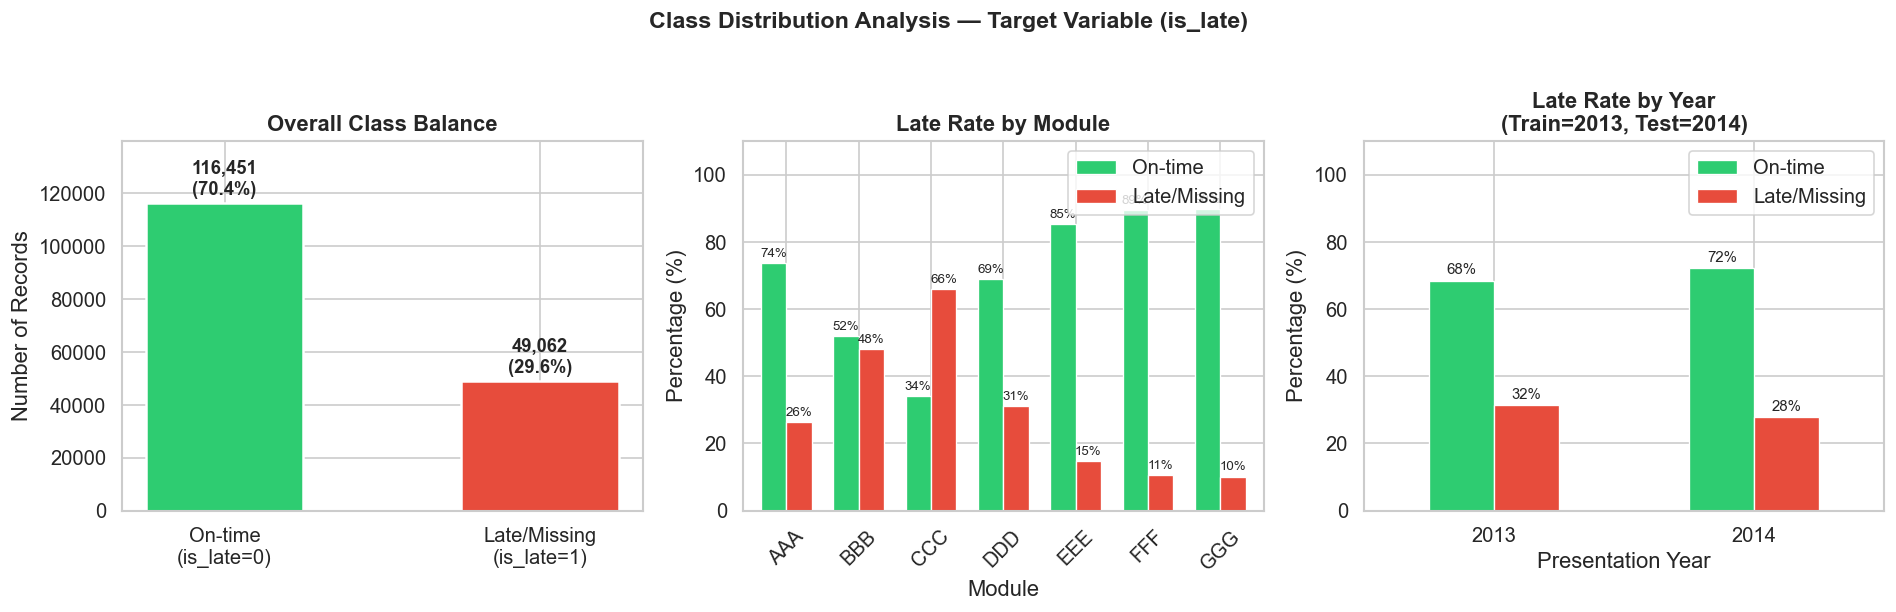

Chart saved to reports/01_class_balance.png

 Late rate by module:
is_late      late_%
code_module        
AAA            26.2
BBB            48.1
CCC            66.0
DDD            31.2
EEE            14.7
FFF            10.6
GGG            10.1

 Late rate by year:
is_late  late_%
year           
2013       31.6
2014       27.9


In [14]:
# ── Cell 4: Class Imbalance Visualisation ─-

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Class Distribution Analysis — Target Variable (is_late)',
             fontsize=14, fontweight='bold', y=1.02)

# ── Plot 1: Overall class balance
counts = target_df['is_late'].value_counts().sort_index()
labels = ['On-time\n(is_late=0)', 'Late/Missing\n(is_late=1)']
colors = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white',
                   linewidth=1.5, width=0.5)
axes[0].set_title('Overall Class Balance', fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].set_ylim(0, counts.max() * 1.2)

# Add count + percentage labels on bars
for bar, count in zip(bars, counts.values):
    pct = count / len(target_df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

#Plot 2: Class balance by code_module
module_balance = (target_df.groupby(['code_module', 'is_late'])
                            .size()
                            .unstack(fill_value=0))
module_balance_pct = module_balance.div(module_balance.sum(axis=1), axis=0) * 100

module_balance_pct.plot(
    kind='bar', ax=axes[1], color=colors,
    edgecolor='white', linewidth=0.8, width=0.7
)
axes[1].set_title('Late Rate by Module', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Module')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['On-time', 'Late/Missing'], loc='upper right')
axes[1].set_ylim(0, 110)

# Add % labels
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f%%', fontsize=8, padding=2)

#Plot 3: Class balance by presentation year (2013 vs 2014)
# Extract year from code_presentation (e.g. '2013J' → '2013')
target_df['year'] = target_df['code_presentation'].str[:4]

year_balance = (target_df.groupby(['year', 'is_late'])
                          .size()
                          .unstack(fill_value=0))
year_balance_pct = year_balance.div(year_balance.sum(axis=1), axis=0) * 100

year_balance_pct.plot(
    kind='bar', ax=axes[2], color=colors,
    edgecolor='white', linewidth=0.8, width=0.5
)
axes[2].set_title('Late Rate by Year\n(Train=2013, Test=2014)', fontweight='bold')
axes[2].set_ylabel('Percentage (%)')
axes[2].set_xlabel('Presentation Year')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(['On-time', 'Late/Missing'], loc='upper right')
axes[2].set_ylim(0, 110)

for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.0f%%', fontsize=9, padding=2)

plt.tight_layout()

# Save to reports folder for report
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/01_class_balance.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart saved to reports/01_class_balance.png")

# ── Key insight summary 
print("\n Late rate by module:")
print(module_balance_pct[[1]].rename(columns={1:'late_%'}).round(1).to_string())
print("\n Late rate by year:")
print(year_balance_pct[[1]].rename(columns={1:'late_%'}).round(1).to_string())

In [15]:
# Cell 5: Demographic Distribution Analysis

print("student_info columns:", student_info.columns.tolist())
print(f"Shape: {student_info.shape}")
student_info.head(3)

student_info columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
Shape: (32593, 12)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn


In [16]:
#Cell 5b: Merge demographics with target variable
# Each student appears once in student_info but multiple times in target_df
# (once per assessment). We merge on id_student + module + presentation.

target_with_demo = target_df.merge(
    student_info[['id_student', 'code_module', 'code_presentation',
                  'gender', 'region', 'highest_education',
                  'imd_band', 'age_band', 'disability', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

print(f"Target + demographics shape: {target_with_demo.shape}")
print(f"Missing values after merge:\n{target_with_demo[['gender','region','imd_band','age_band','disability']].isna().sum()}")

Target + demographics shape: (165513, 20)
Missing values after merge:
gender           0
region           0
imd_band      7229
age_band         0
disability       0
dtype: int64


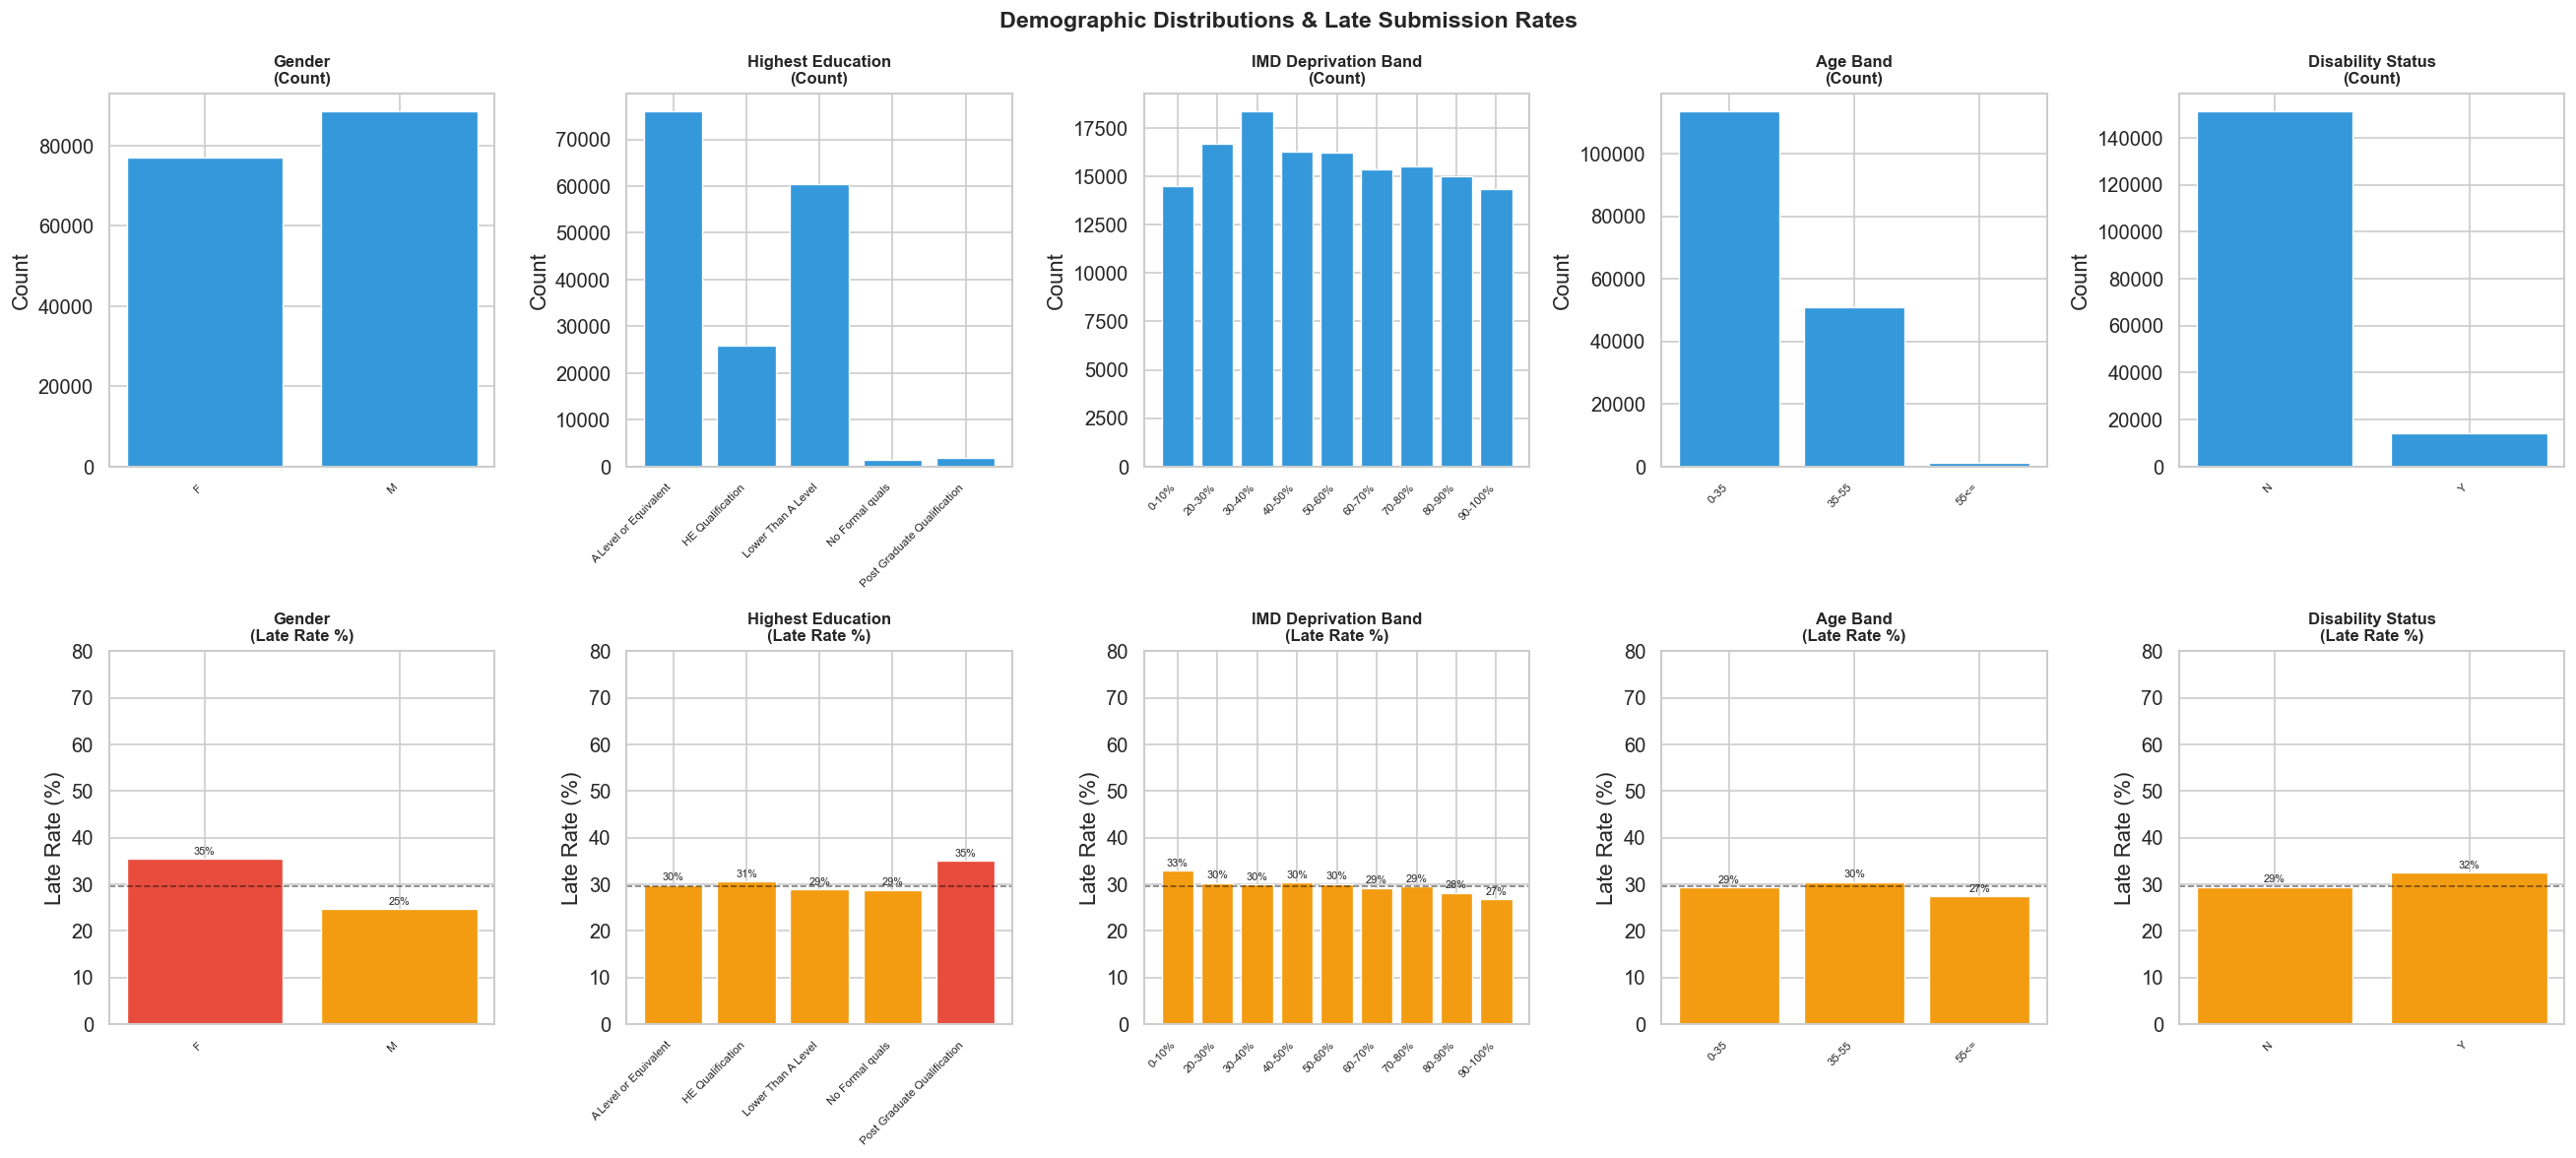

Chart saved to reports/02_demographic_distributions.png


In [17]:
# Cell 5c: Plot demographic distributions & late rates

demographic_cols = {
    'gender':            'Gender',
    'highest_education': 'Highest Education',
    'imd_band':          'IMD Deprivation Band',
    'age_band':          'Age Band',
    'disability':        'Disability Status'
}

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.suptitle('Demographic Distributions & Late Submission Rates',
             fontsize=14, fontweight='bold')

# Define a consistent ordering for IMD band (low to high deprivation)
imd_order = ['0-10%','10-20%','20-30%','30-40%','40-50%',
             '50-60%','60-70%','70-80%','80-90%','90-100%']

for idx, (col, label) in enumerate(demographic_cols.items()):
    ax_top = axes[0, idx]   # top row: raw counts
    ax_bot = axes[1, idx]   # bottom row: late rate %

    # Get ordered categories
    if col == 'imd_band':
        cats = [c for c in imd_order if c in target_with_demo[col].dropna().unique()]
    else:
        cats = sorted(target_with_demo[col].dropna().unique())

    col_data = target_with_demo[target_with_demo[col].notna()]

    # ── Top row: count distribution ──────────────────────────────────────────
    counts = col_data[col].value_counts().reindex(cats, fill_value=0)
    ax_top.bar(range(len(cats)), counts.values, color='#3498db',
               edgecolor='white', linewidth=0.8)
    ax_top.set_title(f'{label}\n(Count)', fontsize=10, fontweight='bold')
    ax_top.set_xticks(range(len(cats)))
    ax_top.set_xticklabels(cats, rotation=45, ha='right', fontsize=7)
    ax_top.set_ylabel('Count')

    # ── Bottom row: late rate per category ───────────────────────────────────
    late_rates = (col_data.groupby(col)['is_late']
                           .mean()
                           .reindex(cats, fill_value=0) * 100)
    colors_bar = ['#e74c3c' if r > 35 else '#f39c12' if r > 20 else '#2ecc71'
                  for r in late_rates.values]
    ax_bot.bar(range(len(cats)), late_rates.values, color=colors_bar,
               edgecolor='white', linewidth=0.8)
    ax_bot.set_title(f'{label}\n(Late Rate %)', fontsize=10, fontweight='bold')
    ax_bot.set_xticks(range(len(cats)))
    ax_bot.set_xticklabels(cats, rotation=45, ha='right', fontsize=7)
    ax_bot.set_ylabel('Late Rate (%)')
    ax_bot.set_ylim(0, 80)
    ax_bot.axhline(y=target_df['is_late'].mean()*100, color='black',
                   linestyle='--', linewidth=1, alpha=0.5, label='Overall avg')

    # Add value labels
    for i, v in enumerate(late_rates.values):
        ax_bot.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=6.5)

plt.tight_layout()
plt.savefig('../reports/02_demographic_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart saved to reports/02_demographic_distributions.png")

In [18]:
# Cell 5d: IMD Band fairness table
# IMD = Index of Multiple Deprivation. Higher % = more deprived area.
# If students from deprived areas have higher late rates, our model may
# disproportionately flag them , a fairness concern.

print("\n IMD Band Late Rate Table (Fairness Baseline):")
print("─" * 55)
imd_stats = (target_with_demo[target_with_demo['imd_band'].notna()]
             .groupby('imd_band')['is_late']
             .agg(['count', 'sum', 'mean'])
             .rename(columns={'count':'total', 'sum':'n_late', 'mean':'late_rate'}))
imd_stats['late_rate_%'] = (imd_stats['late_rate'] * 100).round(1)
imd_stats = imd_stats.reindex([c for c in imd_order if c in imd_stats.index])
print(imd_stats[['total', 'n_late', 'late_rate_%']].to_string())
print("\n Note: Significant variation in late rate across IMD bands")
print("    will be revisited in Chapter 6 (Fairness Analysis)")

# Disability late rate
print("\n Disability Status Late Rate:")
print("─" * 40)
dis_stats = (target_with_demo[target_with_demo['disability'].notna()]
             .groupby('disability')['is_late']
             .agg(['count', 'sum', 'mean'])
             .rename(columns={'count':'total', 'sum':'n_late', 'mean':'late_rate'}))
dis_stats['late_rate_%'] = (dis_stats['late_rate'] * 100).round(1)
print(dis_stats[['total', 'n_late', 'late_rate_%']].to_string())


 IMD Band Late Rate Table (Fairness Baseline):
───────────────────────────────────────────────────────
          total  n_late  late_rate_%
imd_band                            
0-10%     14503    4773         32.9
20-30%    16687    5055         30.3
30-40%    18355    5489         29.9
40-50%    16262    4943         30.4
50-60%    16201    4865         30.0
60-70%    15361    4482         29.2
70-80%    15503    4568         29.5
80-90%    14996    4222         28.2
90-100%   14348    3847         26.8

 Note: Significant variation in late rate across IMD bands
    will be revisited in Chapter 6 (Fairness Analysis)

 Disability Status Late Rate:
────────────────────────────────────────
             total  n_late  late_rate_%
disability                             
N           151285   44445         29.4
Y            14228    4617         32.5
